# Unsupervised Machine Learning

# K - Means Clusterring

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = sns.load_dataset("iris")
X = data.drop("species",axis=1)
X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
data.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [4]:
data.shape

(150, 5)

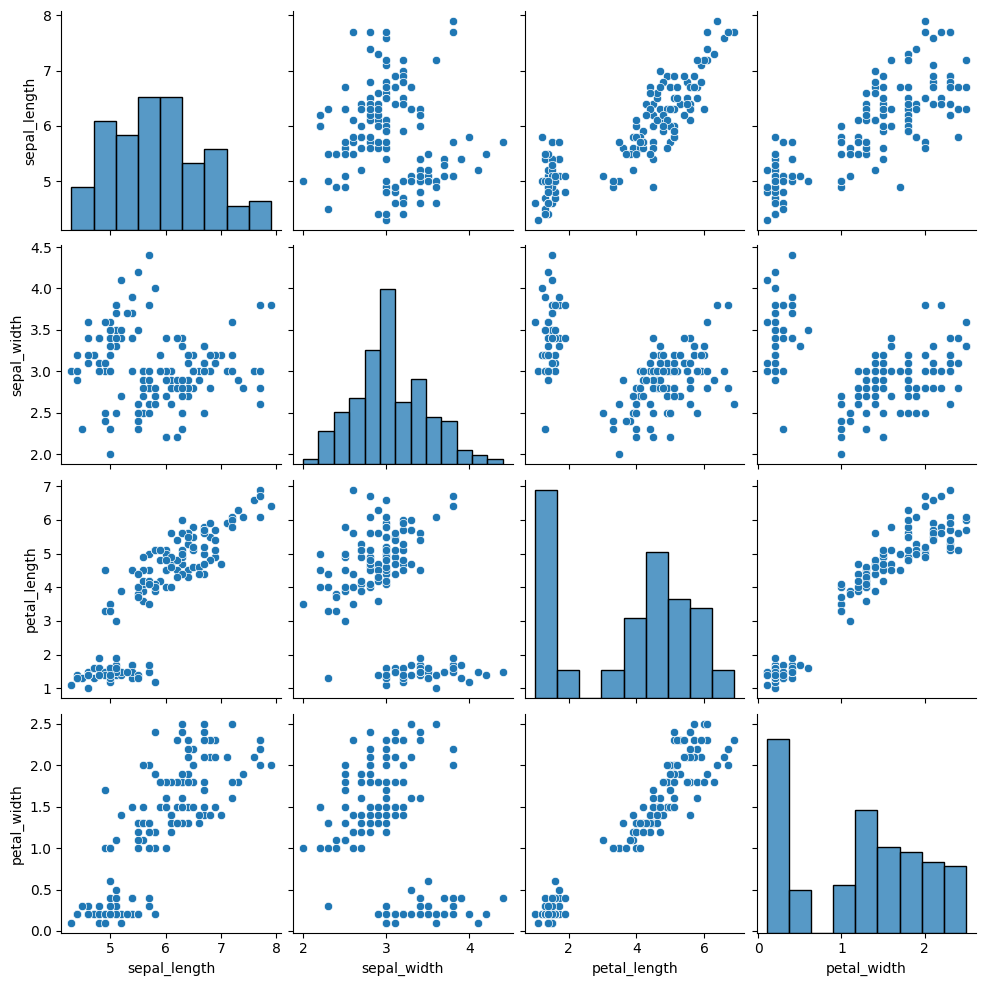

In [5]:
sns.pairplot(data=data)
plt.savefig("iris.jpg")
plt.show()

In [6]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
from sklearn.cluster import KMeans
wcss = []
for i in range(2,21):
    km = KMeans(n_clusters=i,init='k-means++',random_state=42)
    km.fit(X)
    wcss.append(km.inertia_)

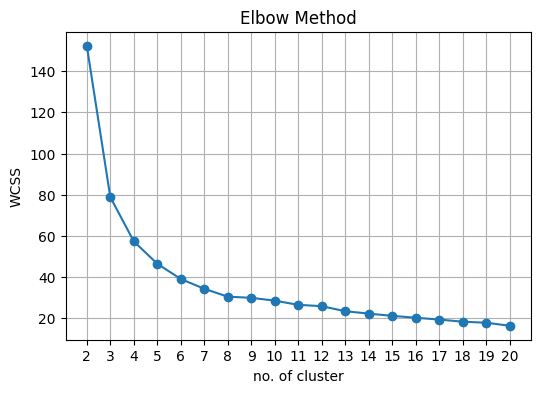

In [9]:
plt.figure(figsize=(6,4))
plt.plot([i for i in range(2,21)],wcss,marker="o")
plt.xlabel("no. of cluster")
plt.xticks([i for i in range(2,21)])
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.savefig("Elbow_Method.jpg")
plt.show()

In [10]:
kmn = KMeans(
    n_clusters=3,
    init="k-means++",
    random_state=42,
    n_init=10
)
X["Predict"] = kmn.fit_predict(X)

In [11]:
X

,sepal_length,sepal_width,petal_length,petal_width,Predict
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,0
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


<Figure size 600x400 with 0 Axes>

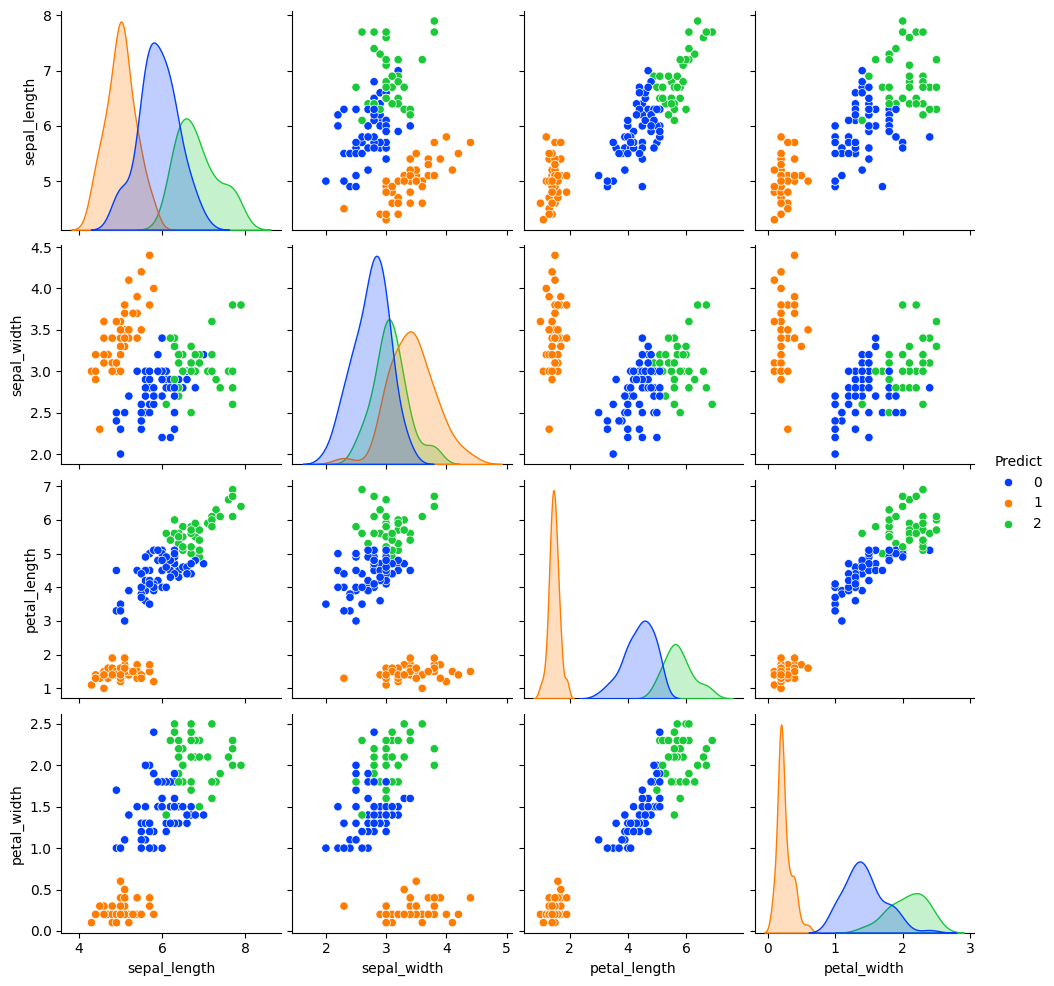

In [12]:
plt.figure(figsize=(6,4))
sns.pairplot(data=X,hue="Predict",palette="bright")
plt.savefig("Predict.jpg")
plt.show()

In [13]:
org_data = sns.load_dataset("iris")
org_data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Figure size 600x400 with 0 Axes>

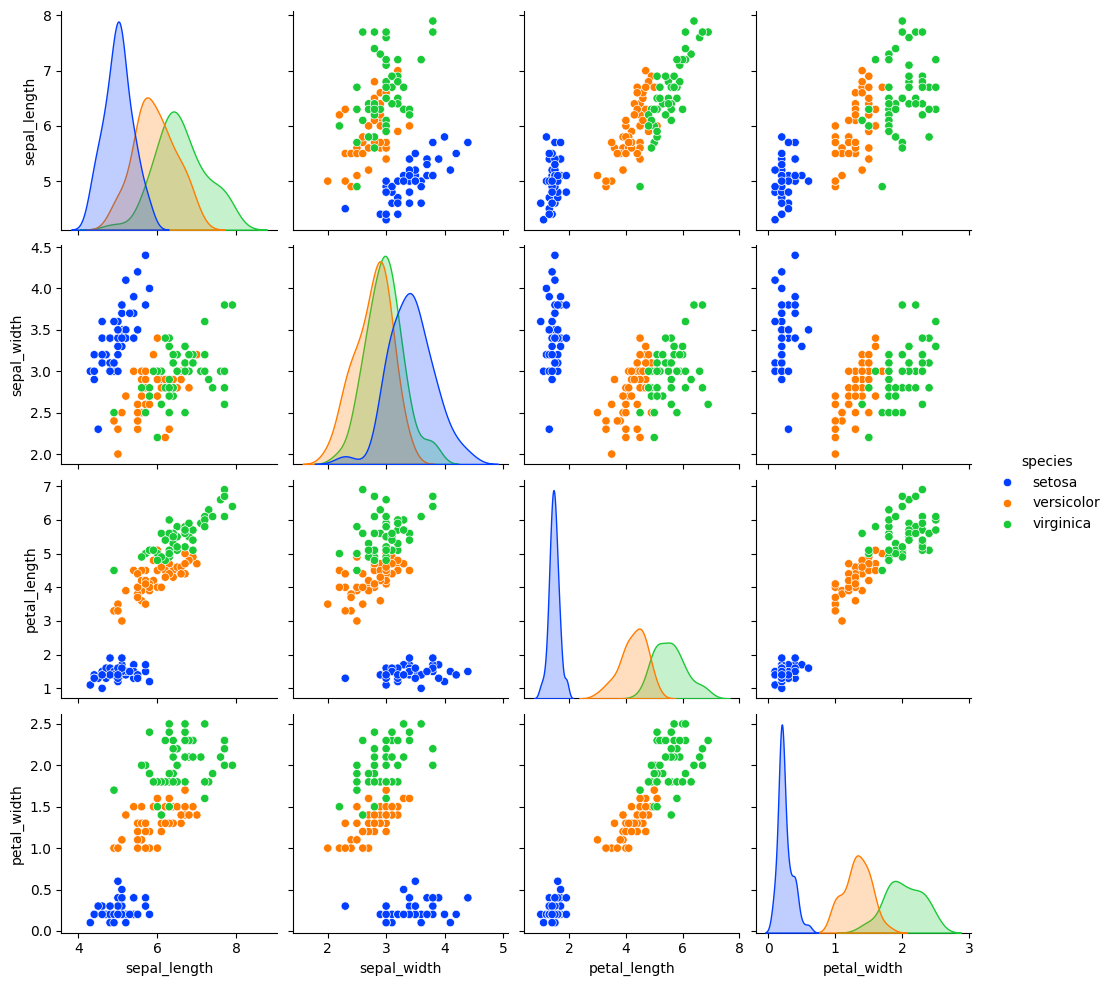

In [14]:
plt.figure(figsize=(6,4))
sns.pairplot(data=org_data,hue="species",palette="bright")
plt.savefig("Original.jpg")
plt.show()